<a href="https://colab.research.google.com/github/LilianaHerrera/Maestria/blob/main/Clase_Final_Taxi_IA_Cloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# De Databricks a producción: estimador de tarifa de taxi

**Continuación del proyecto integrador, llevado a una aplicación pública**
Curso: Computación en la Nube — Maestría en Ciencia de Datos · Clase final

---

## ¿Qué se hará en este notebook?

En el bloque de Databricks se analizó el dataset de taxis de Nueva York y se entrenó un modelo para **estimar la tarifa de un viaje** (`fare_amount`). Ese trabajo terminó en un dashboard interno.

Esta sesión toma el mismo problema y lo lleva un paso más allá: lo publica como una **aplicación web** que cualquier persona puede usar.

> Como el modelo de Databricks es de Spark/MLlib, aquí se reentrena una versión equivalente en **scikit-learn**, más liviana para desplegar.

---

## Herramientas que se usarán (todas libres)

| Herramienta | Qué es | Para qué se usa aquí |
|---|---|---|
| **scikit-learn** | Librería de machine learning en Python | Entrenar el modelo que estima la tarifa del viaje |
| **Gradio** | Librería para crear interfaces web | Construir el formulario donde se ingresan los datos del viaje |
| **FastAPI** | Framework para crear APIs | Exponer el modelo como un servicio (`/predict`) que devuelve la tarifa |
| **Docker** | Tecnología de contenedores | Empaquetar la aplicación con todo lo necesario para que funcione igual en cualquier lugar |
| **Hugging Face Spaces** | Plataforma de despliegue gratuita | Publicar la aplicación en internet, sin tarjeta ni servidores que administrar |

---

**Nota:** este notebook es una plantilla. Las indicaciones **"PARA LA ACTIVIDAD"** señalan qué adaptar para aplicarlo a otro caso.

## Paso 0 — Instalación de dependencias

In [1]:
# PASO 0 — Instalación de dependencias
# Se instalan solo las librerías que Google Colab no trae por defecto.
# (No se tocan numpy, pandas ni scikit-learn: ya vienen en Colab y reinstalarlas puede dañar el entorno.)
#
# Qué se instala y para qué:
#   gradio          -> construye la interfaz web (el formulario de la aplicación)
#   fastapi         -> construye la API (la ruta /predict que devuelve la tarifa)
#   uvicorn         -> servidor que mantiene la aplicación en ejecución
#   httpx           -> permite probar la API desde el propio notebook
#   huggingface_hub -> sube la aplicación a Hugging Face para publicarla
#
# La opción -q ("quiet") reduce los mensajes de instalación.
!pip install -q gradio fastapi "uvicorn[standard]" httpx huggingface_hub

print("Dependencias instaladas")   # confirma que la instalación terminó

Dependencias instaladas


## Paso 1 — Entrenamiento del modelo

En este paso se entrena el modelo que **estima la tarifa de un viaje** (`fare_amount`). Es un problema de **regresión**: la salida es un número (la tarifa en dólares), calculado a partir de cinco variables del viaje: distancia, duración, número de pasajeros, hora de recogida y si es fin de semana.

### ¿De dónde salen los datos?

Son los del **dataset de taxis de Nueva York** trabajado en Databricks (el mismo del proyecto integrador). Hay dos formas de traerlos a este notebook:

1. **Datos reales (recomendado para la actividad).** En Databricks se construyó la tabla de características `taxi_2024_01_features`. Esa tabla se exporta como archivo CSV y se carga aquí con `pd.read_csv("taxi_features.csv")`.

2. **Datos de ejemplo (por defecto).** Para que el notebook se ejecute sin descargar nada, la función `generar_datos()` crea datos sintéticos con la **misma estructura y las mismas relaciones** del dataset real (a mayor distancia y duración, mayor tarifa; recargo en hora pico, etc.).

En ambos casos el resultado es el mismo: una tabla con las cinco variables de entrada (`X`) y la tarifa a predecir (`y`), que alimenta el entrenamiento del modelo.

> **PARA LA ACTIVIDAD:** para usar los datos reales, reemplazar la línea `X, y = generar_datos()` por la carga del CSV exportado de Databricks.

In [2]:
# PASO 1 — Librerías necesarias para el entrenamiento

import joblib                                          # guardar y cargar el modelo entrenado (archivo modelo.pkl)
import numpy as np                                     # operaciones numéricas y generación de datos
import pandas as pd                                    # manejo de los datos en forma de tabla (DataFrame)

from sklearn.ensemble import RandomForestRegressor     # algoritmo de regresión que estimará la tarifa
from sklearn.model_selection import train_test_split   # separa los datos en entrenamiento y prueba
from sklearn.metrics import mean_absolute_error, r2_score  # métricas para medir qué tan bien predice el modelo

In [3]:
# Configuración inicial
RANDOM_STATE = 42                            # semilla fija: hace que los resultados sean siempre los mismos (reproducibles)
rng = np.random.default_rng(RANDOM_STATE)    # generador de números aleatorios, usado para crear los datos

# Variables de entrada del modelo (siempre en este orden)
FEATURES = ["trip_distance", "trip_duration_min", "passenger_count", "pickup_hour", "is_weekend"]


def generar_datos(n=6000):
    """
    Crea n viajes de taxi 'de ejemplo' que imitan al dataset real de Databricks.
    Devuelve dos cosas: las variables de cada viaje (X) y su tarifa (y).
    """
    # Distancia en millas. La distribución 'gamma' produce muchos viajes cortos y pocos largos
    # (como en la realidad). Se limita el rango a entre 0.3 y 30 millas.
    distancia = rng.gamma(2.0, 1.4, n).clip(0.3, 30).round(2)

    hora      = rng.integers(0, 24, n)              # hora de recogida: un número entre 0 y 23
    finde     = rng.binomial(1, 2/7, n)             # ¿fin de semana? 1 = sí, 0 = no (2 de cada 7 días)
    pasajeros = rng.choice([1,1,1,2,2,3,4,5,6], n)  # número de pasajeros (lo más común es 1)

    # Velocidad promedio en millas por hora, con variación por el tráfico (≈ 18 mph)
    velocidad = (18 + rng.normal(0, 3, n)).clip(8, 30)
    # Duración del viaje en minutos = distancia / velocidad, más una pequeña variación
    duracion  = (distancia/velocidad*60 + rng.normal(0, 1.5, n)).clip(1, 120).round(1)

    # Marcas de hora pico (mañana 7-9 y tarde 17-19, solo entre semana) y de madrugada (0-5)
    pico  = (((hora>=7)&(hora<=9)) | ((hora>=17)&(hora<=19))) & (finde==0)
    noche = (hora>=0) & (hora<=5)

    # Tarifa estilo Nueva York: tarifa base + cobro por milla + cobro por minuto
    # + recargo en hora pico + recargo nocturno - pequeño descuento de fin de semana
    # + un poco de ruido aleatorio (para que no sea perfecta). Nunca baja de 3 dólares.
    tarifa = (3.0 + 2.5*distancia + 0.4*duracion + pico*3.0 + noche*1.0 - finde*0.5
              + rng.normal(0, 1.0, n)).clip(3, None).round(2)

    # Se arma una tabla con las variables de cada viaje
    df = pd.DataFrame({"trip_distance":distancia, "trip_duration_min":duracion,
                       "passenger_count":pasajeros, "pickup_hour":hora, "is_weekend":finde})
    # Devuelve X (las variables, en el orden de FEATURES) e y (la tarifa a predecir)
    return df[FEATURES], tarifa


# Se generan los datos de ejemplo.
# PARA LA ACTIVIDAD: en su lugar, cargar los datos reales exportados de Databricks, por ejemplo:
#   datos = pd.read_csv("taxi_features.csv");  X = datos[FEATURES];  y = datos["fare_amount"]
X, y = generar_datos()

# Se separan los datos: 80% para entrenar el modelo y 20% para probar qué tan bien predice
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Se entrena el modelo Random Forest: aprende la relación entre las variables y la tarifa
#   n_estimators=250 -> combina 250 árboles de decisión
#   max_depth=16     -> cada árbol llega hasta 16 niveles de profundidad
#   n_jobs=-1        -> usa todos los núcleos del procesador para entrenar más rápido
modelo = RandomForestRegressor(n_estimators=250, max_depth=16,
                               random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)

In [4]:
# Se evalúa el modelo con los datos de prueba (los que NO se usaron para entrenar)
predicciones = modelo.predict(Xte)        # tarifas estimadas para los viajes de prueba

# MAE (error medio absoluto): en promedio, cuántos dólares se desvía la estimación de la tarifa real
print(f"Error medio (MAE): ${mean_absolute_error(yte, predicciones):.2f}")

# R2: qué tan bien explica el modelo la tarifa (1.0 = ajuste perfecto, 0 = no explica nada)
print(f"R2: {r2_score(yte, predicciones):.3f}")

# Se guarda el modelo entrenado y la lista de variables en un archivo (modelo.pkl).
# Ese archivo es el que usará la aplicación para predecir, sin tener que volver a entrenar.
joblib.dump({"modelo": modelo, "features": FEATURES}, "modelo.pkl")
print("Modelo guardado en modelo.pkl")

Error medio (MAE): $0.95
R2: 0.975
Modelo guardado en modelo.pkl


---
# Utilidad del modelo

Un modelo entrenado no sirve de nada si no se sabe **para qué usarlo**. Antes de desplegarlo, en esta sección se demuestra su utilidad práctica con seis análisis breves:

1. **Estimación por lote** — calcular la tarifa de muchos viajes a la vez.
2. **Simulador** — ver cómo cambia la tarifa según la hora del día.
3. **Explicación** — entender qué variables pesan más en una estimación.
4. **Calidad en dólares** — cuánto se equivoca el modelo, en promedio.
5. **Comparación de modelos** — elegir el que mejor predice.
6. **Insight** — descubrir patrones útiles en los datos.

Cada análisis utiliza el modelo ya entrenado (`modelo`) y la función `generar_datos()` definida en el paso anterior.

## 1) Estimación de un lote de viajes

Viajes con mayor tarifa estimada:


,trip_distance,trip_duration_min,passenger_count,pickup_hour,is_weekend,tarifa_estimada
145,11.23,43.3,2,15,0,46.80
94,9.88,33.4,2,15,1,42.08
96,8.36,29.4,1,17,0,36.17
117,8.19,27.5,4,3,0,35.27
147,8.03,21.1,5,22,0,32.76
100,7.88,24.4,1,17,1,31.91
62,6.32,32.0,6,1,0,31.05
73,5.85,24.8,2,8,0,28.89
22,6.19,21.3,1,8,0,26.89
148,6.41,14.4,1,4,0,26.65


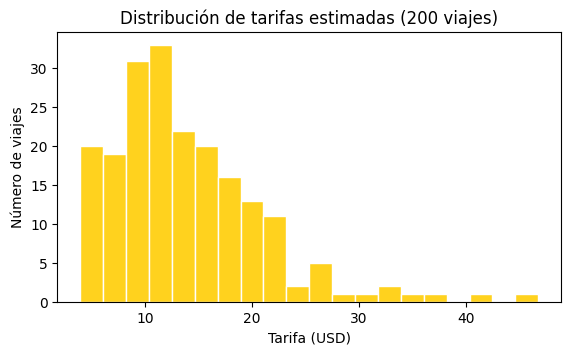

In [5]:
# Análisis 1 — Estimación por lote
# Objetivo: mostrar que el modelo puede estimar la tarifa de MUCHOS viajes a la vez,
# no solo de uno. Es lo que haría, por ejemplo, una flota de taxis o una app de transporte.

import pandas as pd
import matplotlib.pyplot as plt

# Se crean 200 viajes de ejemplo (solo las variables; la tarifa real no se necesita aquí).
# PARA LA ACTIVIDAD: cargar viajes reales ->  viajes = pd.read_csv("viajes.csv")
viajes, _ = generar_datos(200)
viajes = viajes.reset_index(drop=True)              # reordena el índice de la tabla (0, 1, 2, ...)

# El modelo estima la tarifa de cada viaje y el resultado se guarda en una columna nueva
viajes["tarifa_estimada"] = modelo.predict(viajes[FEATURES]).round(2)

# Se ordenan de mayor a menor tarifa y se muestran los 10 viajes más caros
caros = viajes.sort_values("tarifa_estimada", ascending=False).head(10)
print("Viajes con mayor tarifa estimada:")
display(caros)

# Se guarda la tabla completa (con la tarifa estimada) en un archivo CSV descargable
viajes.to_csv("viajes_estimados.csv", index=False)

# Histograma: muestra cómo se reparten las tarifas estimadas (cuántos viajes baratos y cuántos caros)
plt.figure(figsize=(6.5, 3.5))
plt.hist(viajes["tarifa_estimada"], bins=20, color="#FFD21E", edgecolor="white")
plt.title(f"Distribución de tarifas estimadas ({len(viajes)} viajes)")
plt.xlabel("Tarifa (USD)")
plt.ylabel("Número de viajes")
plt.show()

## 2) Simulador: efecto de la hora del dia sobre la tarifa

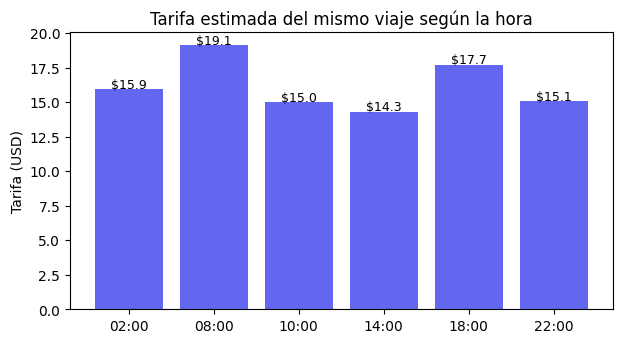

El mismo viaje cuesta más en hora pico (8:00 y 18:00) por el recargo.


In [6]:
# Análisis 2 — Simulador: ¿cómo cambia la tarifa según la hora?
# Objetivo: tomar UN viaje y ver cuánto cambia su tarifa estimada solo por cambiar la hora,
# dejando todo lo demás igual. Así se observa el efecto del recargo en hora pico.

import pandas as pd
import matplotlib.pyplot as plt

# Un viaje de ejemplo (3 millas, 11 minutos, 1 pasajero, entre semana).
# PARA LA ACTIVIDAD: cambiar estos valores por el viaje que se quiera evaluar.
viaje = {"trip_distance": 3, "trip_duration_min": 11, "passenger_count": 1,
         "pickup_hour": 14, "is_weekend": 0}

# Horas del día que se van a probar
horas = [2, 8, 10, 14, 18, 22]

# Para cada hora se copia el mismo viaje cambiando solo la hora, y se estima la tarifa.
tarifas = {}                                          # guardará los resultados: {"08:00": 19.1, ...}
for h in horas:
    viaje_a_esa_hora = {**viaje, "pickup_hour": h}    # el mismo viaje, pero con la hora h
    fila = pd.DataFrame([viaje_a_esa_hora])[FEATURES] # se convierte en una tabla de una sola fila
    tarifa = float(modelo.predict(fila)[0])           # el modelo estima la tarifa de ese viaje
    tarifas[f"{h:02d}:00"] = tarifa                   # se guarda usando la hora como etiqueta

# Gráfico de barras: una barra por hora, con la tarifa estimada escrita encima
plt.figure(figsize=(7, 3.6))
barras = plt.bar(tarifas.keys(), tarifas.values(), color="#6366f1")
plt.title("Tarifa estimada del mismo viaje según la hora")
plt.ylabel("Tarifa (USD)")
for barra, v in zip(barras, tarifas.values()):        # escribe el valor encima de cada barra
    plt.text(barra.get_x() + barra.get_width()/2, v + 0.1, f"${v:.1f}", ha="center", fontsize=9)
plt.show()

print("El mismo viaje cuesta más en hora pico (8:00 y 18:00) por el recargo.")

## 3) Explicacion de una estimacion

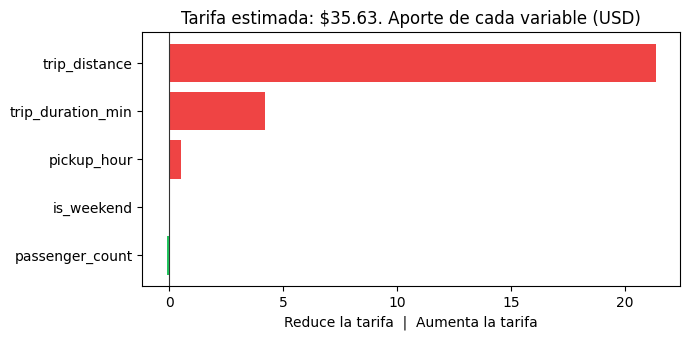

In [7]:
# Análisis 3 — Explicación de una estimación
# Objetivo: entender POR QUÉ el modelo estima cierta tarifa para un viaje concreto,
# es decir, cuánto aporta cada variable (distancia, hora, etc.). El modelo deja de ser una "caja negra".

import pandas as pd
import matplotlib.pyplot as plt

# Viaje que se quiere explicar (8 millas, 28 minutos, a las 18:00 entre semana = hora pico).
viaje = {"trip_distance": 8, "trip_duration_min": 28, "passenger_count": 1,
         "pickup_hour": 18, "is_weekend": 0}

# Valores "neutrales" = la mediana de muchos viajes (un viaje típico).
# Sirven como punto de comparación para medir el efecto de cada variable.
ref, _ = generar_datos(500)
neutral = ref[FEATURES].median()

# Tarifa que el modelo estima para ESTE viaje (el punto de partida)
base = float(modelo.predict(pd.DataFrame([viaje])[FEATURES])[0])

# Para cada variable: se reemplaza su valor por el neutral y se mide cuánto cambia la tarifa.
# Esa diferencia es el "aporte" de la variable (positivo = sube la tarifa, negativo = la baja).
contrib = {}
for f in FEATURES:
    viaje_neutralizado = {**viaje, f: neutral[f]}   # mismo viaje, pero con esa variable en su valor típico
    tarifa_sin_esa_variable = float(modelo.predict(pd.DataFrame([viaje_neutralizado])[FEATURES])[0])
    contrib[f] = base - tarifa_sin_esa_variable     # cuánto aportó esa variable a la tarifa

# Se ordenan los aportes de menor a mayor (para que el gráfico quede ordenado)
contrib = dict(sorted(contrib.items(), key=lambda t: t[1]))

# Color de cada barra: rojo si la variable AUMENTA la tarifa, verde si la REDUCE
col = ["#ef4444" if c > 0 else "#22c55e" for c in contrib.values()]

# Gráfico de barras horizontales: el aporte (en dólares) de cada variable
plt.figure(figsize=(7, 3.5))
plt.barh(list(contrib), list(contrib.values()), color=col)
plt.axvline(0, color="#333", linewidth=0.8)         # línea vertical en cero (variable sin efecto)
plt.title(f"Tarifa estimada: ${base:.2f}. Aporte de cada variable (USD)")
plt.xlabel("Reduce la tarifa  |  Aumenta la tarifa")
plt.tight_layout()
plt.show()

## 4) Calidad del modelo en dolares

In [8]:
# Análisis 4 — Calidad del modelo en dólares
# Objetivo: medir, en una cifra fácil de entender, qué tan bueno es el modelo:
# cuántos dólares se equivoca, en promedio, al estimar la tarifa de un viaje.

from sklearn.metrics import mean_absolute_error

# Se comparan las tarifas REALES de los viajes de prueba (yte) con las que el modelo ESTIMA (modelo.predict(Xte)).
# El MAE (error medio absoluto) es el promedio de esas diferencias, tomadas en valor absoluto.
mae = mean_absolute_error(yte, modelo.predict(Xte))

print(f"El modelo estima la tarifa con un error medio de ${mae:.2f} por viaje.")
print("Es decir, en promedio la estimación se desvía esa cantidad respecto a la tarifa real.")
print("Cuanto más bajo es este valor, mejor es el modelo.")

El modelo estima la tarifa con un error medio de $0.95 por viaje.
Es decir, en promedio la estimación se desvía esa cantidad respecto a la tarifa real.
Cuanto más bajo es este valor, mejor es el modelo.


## 5) Comparacion de modelos

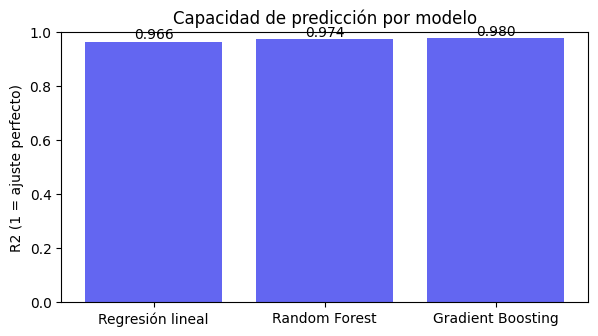

Mejor modelo: Gradient Boosting


In [9]:
# Análisis 5 — Comparación de modelos
# Objetivo: no quedarse con un solo modelo "porque sí", sino comparar varios y elegir con criterio
# el que mejor predice la tarifa. (En Databricks ya se compararon dos; aquí se agrega un tercero.)

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Los tres modelos candidatos (todos predicen un número: la tarifa):
#   - Regresión lineal : el más simple; traza una "línea" entre las variables y la tarifa.
#   - Random Forest    : combina muchos árboles de decisión (es el que usa la aplicación).
#   - Gradient Boosting: construye árboles que van corrigiendo los errores de los anteriores.
candidatos = {
    "Regresión lineal":  LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=250, max_depth=16, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

# Se evalúa cada modelo con "validación cruzada" (cv=5): los datos se dividen en 5 partes,
# se entrena y prueba 5 veces, y se promedia. Es más confiable que una sola prueba.
# La métrica es R2: qué tan bien explica el modelo la tarifa (1.0 = perfecto, 0 = nada).
r2 = {}                                              # guardará el R2 promedio de cada modelo
for nombre, modelo_candidato in candidatos.items():
    puntajes = cross_val_score(modelo_candidato, X, y, cv=5, scoring="r2")
    r2[nombre] = puntajes.mean()                     # promedio de las 5 pruebas

# Gráfico de barras: el R2 de cada modelo (barra más alta = mejor)
plt.figure(figsize=(6.8, 3.5))
barras = plt.bar(r2.keys(), r2.values(), color="#6366f1")
plt.ylim(0, 1.0)
plt.ylabel("R2 (1 = ajuste perfecto)")
plt.title("Capacidad de predicción por modelo")
for barra, v in zip(barras, r2.values()):            # escribe el valor encima de cada barra
    plt.text(barra.get_x() + barra.get_width()/2, v + 0.01, f"{v:.3f}", ha="center")
plt.show()

# Se anuncia cuál modelo obtuvo el R2 más alto
print("Mejor modelo:", max(r2, key=r2.get))

## 6) Insight: tarifa media segun la hora

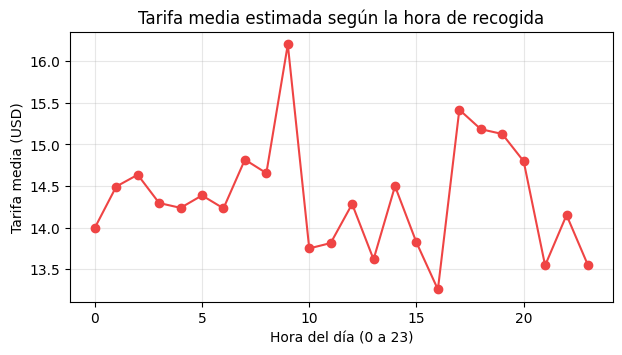

Las horas pico (mañana y tarde) muestran tarifas más altas por el recargo.


In [10]:
# Análisis 6 — Insight: ¿cómo cambia la tarifa media a lo largo del día?
# Objetivo: descubrir un patrón útil en los datos. Aquí se ve a qué horas las tarifas
# tienden a ser más altas, lo que sirve, por ejemplo, para planear precios o turnos.

import matplotlib.pyplot as plt

# Se crean 6000 viajes de ejemplo y el modelo estima la tarifa de cada uno
muestra, _ = generar_datos(6000)
muestra["tarifa"] = modelo.predict(muestra[FEATURES])

# Se agrupan los viajes por hora de recogida y se calcula la tarifa MEDIA de cada hora.
# Resultado: una tarifa promedio para las 0:00, otra para la 1:00, ... hasta las 23:00.
por_hora = muestra.groupby("pickup_hour")["tarifa"].mean()

# Gráfico de línea: tarifa media (eje vertical) frente a la hora del día (eje horizontal)
plt.figure(figsize=(7, 3.5))
plt.plot(por_hora.index, por_hora.values, marker="o", color="#ef4444")
plt.title("Tarifa media estimada según la hora de recogida")
plt.xlabel("Hora del día (0 a 23)")
plt.ylabel("Tarifa media (USD)")
plt.grid(alpha=0.3)
plt.show()

print("Las horas pico (mañana y tarde) muestran tarifas más altas por el recargo.")

---
# Paso 2 — Aplicación: API e interfaz web
El archivo `app.py` ofrece una interfaz (pestañas "Un viaje" y "Lote por CSV") en `/` y una API en `/predict`.

PARA LA ACTIVIDAD: ajustar el esquema `Viaje` y los controles de la interfaz a las variables del caso.

In [11]:
%%writefile app.py
# Esta celda no se ejecuta como código normal: la línea %%writefile guarda todo su
# contenido en un archivo llamado app.py. Ese archivo ES la aplicación que luego se
# empaqueta en el contenedor y se despliega.
"""
Aplicacion de estimacion de tarifa de taxi: API (FastAPI) e interfaz web (Gradio).
- Interfaz web en  /         (pestañas "Un viaje" y "Lote por CSV")
- API en           /predict  (para invocar desde código)
El mismo problema del notebook de Databricks (predecir fare_amount), llevado a producción.
"""
import joblib
import pandas as pd
import gradio as gr
from fastapi import FastAPI
from pydantic import BaseModel, Field

# Se carga el modelo entrenado y la lista de variables desde modelo.pkl.
# (No se entrena aquí: solo se usa el modelo ya guardado en el Paso 1.)
_bundle = joblib.load("modelo.pkl")
MODELO = _bundle["modelo"]
FEATURES = _bundle["features"]

def _tarifa(fila_dict):
    """Recibe los datos de un viaje (un diccionario) y devuelve la tarifa estimada."""
    x = pd.DataFrame([fila_dict])[FEATURES]   # convierte el viaje en una tabla de una fila, en el orden correcto
    return float(MODELO.predict(x)[0])        # el modelo estima la tarifa

# ---------- API (para invocar desde código) ----------
app = FastAPI(title="Estimador de tarifa de taxi", version="1.0")

class Viaje(BaseModel):
    """Define qué datos debe enviar quien use la API y valida sus rangos automáticamente."""
    trip_distance: float     = Field(..., example=3.0)
    trip_duration_min: float = Field(..., example=12.0)
    passenger_count: int     = Field(..., example=1, ge=1, le=6)    # entre 1 y 6 pasajeros
    pickup_hour: int         = Field(..., example=14, ge=0, le=23)  # hora entre 0 y 23
    is_weekend: int          = Field(..., example=0, ge=0, le=1)    # 0 = no, 1 = sí

@app.get("/health")
def health():
    # Ruta de "salud": permite comprobar que la aplicación está viva
    return {"status": "ok"}

@app.post("/predict")
def predict(v: Viaje):
    # Recibe un viaje, estima la tarifa y la devuelve como respuesta (en formato JSON)
    tarifa = _tarifa(v.model_dump())
    return {"tarifa_estimada_usd": round(tarifa, 2)}

# ---------- Interfaz web (lo que ve el usuario) ----------
def _uno(distancia, duracion, pasajeros, hora, fin_de_semana):
    """Pestaña 'Un viaje': toma los valores del formulario y devuelve la tarifa como texto."""
    t = _tarifa({"trip_distance": distancia, "trip_duration_min": duracion,
                 "passenger_count": int(pasajeros), "pickup_hour": int(hora),
                 "is_weekend": int(fin_de_semana)})
    return f"Tarifa estimada: ${t:.2f}"

def _lote(archivo):
    """Pestaña 'Lote': recibe un CSV de viajes y devuelve la tabla con la tarifa estimada de cada uno."""
    df = pd.read_csv(archivo)
    # Si el CSV no trae las columnas necesarias, se avisa con un mensaje claro en vez de fallar
    faltan = [c for c in FEATURES if c not in df.columns]
    if faltan:
        return pd.DataFrame({"Error": [f"Faltan columnas requeridas: {', '.join(faltan)}"]})
    df["tarifa_estimada"] = MODELO.predict(df[FEATURES]).round(2)   # estima la tarifa de todos los viajes
    return df

# Se construye la interfaz con dos pestañas usando Gradio
with gr.Blocks(title="Estimador de tarifa de taxi") as demo:
    gr.Markdown("# Estimador de tarifa de taxi (NYC)")

    # Pestaña 1: estimar UN viaje con controles deslizantes (sliders)
    with gr.Tab("Un viaje"):
        d   = gr.Slider(0.3, 30, value=3.0, step=0.1, label="Distancia (millas)")
        m   = gr.Slider(1, 90, value=12, step=1, label="Duración (minutos)")
        pax = gr.Slider(1, 6, value=1, step=1, label="Pasajeros")
        h   = gr.Slider(0, 23, value=14, step=1, label="Hora de recogida")
        w   = gr.Checkbox(label="Fin de semana")
        btn = gr.Button("Estimar tarifa", variant="primary")
        out = gr.Textbox(label="Resultado")
        btn.click(_uno, [d, m, pax, h, w], out)   # al pulsar el botón se llama a _uno con los valores

    # Pestaña 2: estimar MUCHOS viajes subiendo un archivo CSV
    with gr.Tab("Lote (CSV)"):
        gr.Markdown("Cargar un CSV con las columnas: " + ", ".join(FEATURES))
        arch  = gr.File(type="filepath", label="CSV de viajes")
        tabla = gr.Dataframe(label="Viajes con tarifa estimada")
        arch.change(_lote, arch, tabla)           # al subir el archivo se llama a _lote

# Se "monta" la interfaz web dentro de la misma aplicación, en la ruta "/".
# Resultado: la interfaz queda en "/" y la API en "/predict", en un solo servicio.
app = gr.mount_gradio_app(app, demo, path="/")

Writing app.py


## Paso 3 — Prueba local de la aplicación
La aplicación se ejecuta dentro de Colab para verificar las pestañas. Para continuar, detener la celda.

In [13]:
# Paso 3 — Prueba de la aplicación dentro de Colab
# Objetivo: ejecutar la aplicación aquí mismo para verla funcionar ANTES de desplegarla.

import importlib
import app as app_module          # importa el archivo app.py creado en el paso anterior

# Vuelve a cargar app.py por si se modificó, para usar siempre la versión más reciente
importlib.reload(app_module)

# Lanza la interfaz web (Gradio) dentro del notebook.
# share=True genera además un enlace público temporal para abrirla desde el navegador.
# (Para continuar con las celdas siguientes, detener esta con el botón de stop.)
app_module.demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://50b60685a732b97b31.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Paso 4 — Empaquetado en un contenedor (Docker)

In [14]:
# Paso 4 — Lista de dependencias para el contenedor (requirements.txt)
# Objetivo: anotar las versiones EXACTAS de las librerías que se están usando en Colab,
# para que el contenedor instale esas mismas versiones y la aplicación funcione igual.
# (Así se evita el típico problema de "en Colab servía, pero en el contenedor no".)

# Se importan las librerías solo para leer su número de versión (atributo __version__)
import sklearn, numpy, pandas, joblib, fastapi, uvicorn, pydantic, gradio

# Se arma el texto del archivo: una línea por librería, con el formato  nombre==versión
reqs = f"""scikit-learn=={sklearn.__version__}
pandas=={pandas.__version__}
numpy=={numpy.__version__}
joblib=={joblib.__version__}
fastapi=={fastapi.__version__}
uvicorn[standard]=={uvicorn.__version__}
pydantic=={pydantic.__version__}
gradio=={gradio.__version__}
"""

# Se guarda ese texto en el archivo requirements.txt y se muestra en pantalla para revisarlo
open("requirements.txt", "w").write(reqs)
print(reqs)

scikit-learn==1.6.1
pandas==2.2.2
numpy==2.0.2
joblib==1.5.3
fastapi==0.138.0
uvicorn[standard]==0.49.0
pydantic==2.13.4
gradio==6.19.0



In [15]:
%%writefile Dockerfile
# Paso 4 — Receta para construir la imagen del contenedor (Dockerfile)

# Parte de una imagen base que ya incluye Python 3.11 (la versión "slim" es ligera)
FROM python:3.11-slim

# Define /app como carpeta de trabajo dentro del contenedor
WORKDIR /app

# Copia primero la lista de dependencias (para aprovechar la caché de Docker)
COPY requirements.txt .

# Instala esas dependencias (--no-cache-dir mantiene la imagen más liviana)
RUN pip install --no-cache-dir -r requirements.txt

# Copia el código de la aplicación y el modelo entrenado
COPY app.py modelo.pkl .

# Indica que la aplicación usará el puerto 7860 (el que espera Hugging Face Spaces)
EXPOSE 7860

# Comando que se ejecuta al arrancar el contenedor: levanta la app con uvicorn.
# 0.0.0.0 = aceptar conexiones desde fuera del contenedor; 7860 = el puerto.
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "7860"]

Writing Dockerfile


In [16]:
%%writefile README.md
---
title: Estimador de tarifa de taxi
emoji: 🚕
colorFrom: yellow
colorTo: indigo
sdk: docker
app_port: 7860
pinned: false
---
# Estimador de tarifa de taxi (interfaz y API)
Interfaz en /  ·  API en /predict

Writing README.md


## Paso 5 — Despliegue en Hugging Face Spaces
Hugging Face construye el contenedor y publica la aplicación. Se requiere una cuenta gratuita y un token de tipo Write.
Equivalente en la nube: Google Cloud Run (contenedores serverless), sin costo y sin tarjeta.

In [17]:
# Paso 5 — Despliegue de la aplicación en Hugging Face
# Objetivo: subir los archivos al Space para que Hugging Face construya el contenedor y publique la app.

from getpass import getpass
from huggingface_hub import HfApi, create_repo

# Se pide el token de forma segura (getpass no muestra lo que se escribe) y el usuario de Hugging Face.
HF_TOKEN = getpass("Token de Hugging Face (Write): ")
USUARIO  = input("Usuario de Hugging Face: ").strip()

# Nombre completo del Space:  usuario/taxi-fare-app
SPACE_ID = f"{USUARIO}/taxi-fare-app"

# Crea el Space (de tipo Docker). exist_ok=True: si ya existe, lo reutiliza en vez de fallar.
create_repo(SPACE_ID, repo_type="space", space_sdk="docker", token=HF_TOKEN, exist_ok=True)

# Cliente para interactuar con Hugging Face usando el token
api = HfApi(token=HF_TOKEN)

# Se suben, uno por uno, los archivos que componen la aplicación
for archivo in ["app.py", "requirements.txt", "Dockerfile", "modelo.pkl", "README.md"]:
    api.upload_file(path_or_fileobj=archivo, path_in_repo=archivo,
                    repo_id=SPACE_ID, repo_type="space")
    print("subido:", archivo)

print("\nArchivos subidos. Hugging Face está construyendo la imagen del contenedor.")
print(f"Estado del Space: https://huggingface.co/spaces/{SPACE_ID}")

Token de Hugging Face (Write): ··········
Usuario de Hugging Face: lcherrerap
subido: app.py
subido: requirements.txt
subido: Dockerfile


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/modelo.pkl         :  24%|##4       | 24.0MB / 99.5MB            

subido: modelo.pkl
subido: README.md

Archivos subidos. Hugging Face está construyendo la imagen del contenedor.
Estado del Space: https://huggingface.co/spaces/lcherrerap/taxi-fare-app


### Espera del despliegue
La siguiente celda consulta el estado del Space hasta que pase a "Running".

In [18]:
# Paso 5 (continuación) — Espera a que la aplicación esté lista
# Objetivo: consultar automáticamente el estado del Space hasta que pase a "Running",
# en lugar de revisar la página manualmente.

import time
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN)

print("Esperando a que el Space termine de construirse...")

# Se revisa el estado hasta 60 veces, con pausas de 5 segundos (en total, hasta ~5 minutos)
for _ in range(60):
    estado = api.get_space_runtime(SPACE_ID).stage   # estado actual: BUILDING, RUNNING, etc.
    print("  estado:", estado)

    if estado == "RUNNING":                          # la aplicación ya está disponible
        print(f"\nDisponible: https://huggingface.co/spaces/{SPACE_ID}")
        break

    if "ERROR" in estado:                            # hubo un fallo durante la construcción
        print("\nError en el despliegue. Revisar la pestaña 'Logs' del Space.")
        break

    time.sleep(5)                                    # espera 5 segundos antes de volver a consultar

Esperando a que el Space termine de construirse...
  estado: RUNNING

Disponible: https://huggingface.co/spaces/lcherrerap/taxi-fare-app


### Prueba de la API publicada (cuando el Space indique "Running")

In [19]:
# Paso 5 (final) — Prueba de la API ya publicada
# Objetivo: comprobar que la aplicación en producción responde, enviándole un viaje de ejemplo
# desde fuera (igual que lo haría otro programa).

import requests

# Dirección pública de la API. El patrón es:  https://<usuario>-<nombre-del-space>.hf.space/predict
URL = f"https://{USUARIO}-taxi-fare-app.hf.space/predict"

try:
    # Se envía un viaje de ejemplo (5 millas, 18 min, 1 pasajero, a las 8:00 entre semana)
    # como JSON, y se espera la respuesta hasta 30 segundos.
    r = requests.post(URL, json={"trip_distance": 5, "trip_duration_min": 18,
                                 "passenger_count": 1, "pickup_hour": 8, "is_weekend": 0},
                      timeout=30)
    print("Respuesta en producción:", r.json())   # la tarifa estimada que devuelve la API
except Exception as e:
    # Si algo falla (por ejemplo, el Space aún no está "Running"), se muestra el motivo
    print("Si falla, verificar que el Space indique 'Running'. Detalle:", e)

Respuesta en producción: {'tarifa_estimada_usd': 24.43}


## Paso 6 — Monitoreo y cierre
- `/health` verifica la disponibilidad del servicio.
- La pestaña Logs del Space registra cada petición y error.
- El drift de datos exige reentrenar el modelo con el tiempo.

Equivalente en la nube: Cloud Monitoring / CloudWatch / Azure Monitor.

### Checklist de validación de arquitectura
| Área | Cumplimiento |
|---|---|
| Microservicio independiente (API e interfaz) | Sí |
| Modelo versionado (modelo.pkl en el repositorio) | Sí |
| Build reproducible (Dockerfile) | Sí |
| Sin credenciales en el código (getpass) | Sí |
| Serverless / escala a cero | Sí |


- Token rechazado: debe ser de tipo Write.